# 实战 Kaggle 比赛：图像分类

In [22]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

## Colab：下载并解压数据

先在 Colab 中运行下面的安装单元。CIFAR-10 竞赛数据需要 Kaggle 身份验证并接受竞赛规则：推荐在 Colab 的“密钥”中添加名为 `KAGGLE_API_TOKEN` 的 Secret；如果下载时报 401/403，请先确认已在 Kaggle 页面接受竞赛规则。

In [23]:
%pip install -q kagglehub py7zr

In [24]:
import kagglehub

# 如果没有配置 Colab Secret，可取消下一行注释并按提示登录
# kagglehub.login()

path = kagglehub.competition_download('cifar-10')
print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/cifar-10


In [25]:
import shutil

import py7zr

# kagglehub 返回的目录中包含 train.7z、test.7z 和两个 CSV 文件
competition_dir = Path(path)
root_dir = Path('/content/cifar-10')
root_dir.mkdir(parents=True, exist_ok=True)

for archive_name in ('train.7z', 'test.7z'):
    archive_path = competition_dir / archive_name
    image_dir = root_dir / archive_path.stem
    marker_path = root_dir / f'.{archive_path.stem}_extracted'

    if not archive_path.is_file():
        raise FileNotFoundError(f'未找到压缩文件：{archive_path}')

    if marker_path.exists() and image_dir.is_dir():
        print(f'已解压，跳过：{image_dir}')
        continue

    print(f'正在解压 {archive_name}，请耐心等待……')
    with py7zr.SevenZipFile(archive_path, mode='r') as archive:
        archive.extractall(path=root_dir)
    marker_path.touch()
    print(f'解压完成：{image_dir}')

# 把标签与提交模板复制到统一的数据目录，后续代码只使用 root_dir
for csv_name in ('trainLabels.csv', 'sampleSubmission.csv'):
    source_path = competition_dir / csv_name
    target_path = root_dir / csv_name
    if not source_path.is_file():
        raise FileNotFoundError(f'未找到 CSV 文件：{source_path}')
    if not target_path.exists():
        shutil.copy2(source_path, target_path)

# 完整性检查：CIFAR-10 Kaggle 版本应包含 50,000 张训练图和 300,000 张测试图
expected_counts = {'train': 50_000, 'test': 300_000}
for folder_name, expected_count in expected_counts.items():
    folder_path = root_dir / folder_name
    image_count = sum(1 for _ in folder_path.glob('*.png'))
    print(f'{folder_name}: {image_count:,} 张图片')
    if image_count != expected_count:
        raise RuntimeError(
            f'{folder_name} 图片数量应为 {expected_count:,}，实际为 {image_count:,}；请重新解压。'
        )

print('数据准备完成：', root_dir)

已解压，跳过：/content/cifar-10/train
已解压，跳过：/content/cifar-10/test
train: 50,000 张图片
test: 300,000 张图片
数据准备完成： /content/cifar-10


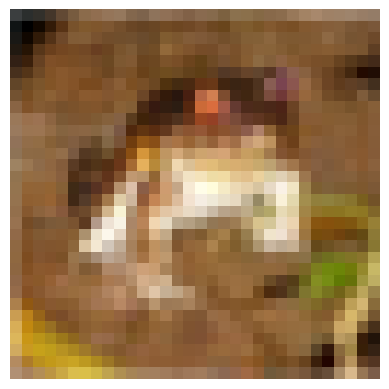

In [26]:
train_dir = root_dir / 'train'
test_dir = root_dir / 'test'
first_image_path = train_dir / '1.png'
first_image = Image.open(first_image_path)
plt.imshow(first_image)
plt.axis('off')
plt.show()

## 加载数据

重定义 Dataset, 方便加载数据

In [27]:
class CIFAR10Dataset(Dataset):
    def __init__(self, root_dir, train=True, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.train = train

        self.classes = [
            "airplane",
            "automobile",
            "bird",
            "cat",
            "deer",
            "dog",
            "frog",
            "horse",
            "ship",
            "truck"
        ]

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(self.classes)
        }

        if self.train:
            self.labels_df = pd.read_csv(
                os.path.join(root_dir, 'trainLabels.csv')
            )

            self.image_dir = os.path.join(
                root_dir,
                'train'
            )

        else:
            self.image_dir = os.path.join(
                root_dir,
                'test'
            )

            self.image_names = os.listdir(self.image_dir)

            self.image_names.sort(
                key=lambda x: int(os.path.splitext(x)[0])
            )

    def __len__(self):
        if self.train:
            return len(self.labels_df)
        else:
            return len(self.image_names)

    def __getitem__(self, index):

        index = int(index)
        if self.train:
            row = self.labels_df.iloc[index]

            image_id = row['id']

            label = self.class_to_idx[
                row['label']
            ]

            image_path = os.path.join(
                self.image_dir,
                f'{image_id}.png'
            )

            image = Image.open(
                image_path
            ).convert("RGB")

            if self.transform:
                image = self.transform(image)

            return image, label

        else:
            image_name = self.image_names[index]

            image_id = int(
                os.path.splitext(image_name)[0]
            )

            image_path = os.path.join(
                self.image_dir,
                image_name
            )

            image = Image.open(
                image_path
            ).convert("RGB")

            if self.transform:
                image = self.transform(image)

            return image, image_id

In [28]:
transform_train = transforms.Compose([
    transforms.Resize(40),
    # 随机裁剪出一个高度和宽度均为40像素的正方形图像，
    # 生成一个面积为原始图像面积0.64～1倍的小正方形，
    # 然后将其缩放为高度和宽度均为32像素的正方形
    transforms.RandomResizedCrop(size=32,scale=(0.64,1),ratio=(1.0,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465],
                         [0.2023, 0.1994, 0.2010])
    ])

transform_test = transforms.Compose([
    transforms.Resize(40),
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465],
                         [0.2023, 0.1994, 0.2010])
    ])


## 划分数据集

将训练集划分一部分为验证集，请注意不要把训练集的 `train_transform` 给测试集和验证集做，测试集和验证集做 `test_transform` 即可

In [29]:
def split_dataset(
    root_dir,
    train_transform,
    val_transform,
    valid_ratio=0.2,
    seed=42
):
    train_ds = CIFAR10Dataset(
        root_dir,
        train=True,
        transform=train_transform
    )

    valid_ds = CIFAR10Dataset(
        root_dir,
        train=True,
        transform=val_transform
    )

    num_samples = len(train_ds)

    generator = torch.Generator().manual_seed(seed)

    indices = torch.randperm(
        num_samples,
        generator=generator
    )

    valid_size = int(num_samples * valid_ratio)

    valid_indices = indices[:valid_size]
    train_indices = indices[valid_size:]

    train_ds = Subset(train_ds, train_indices)
    valid_ds = Subset(valid_ds, valid_indices)

    return train_ds, valid_ds

In [30]:
train_ds,valid_ds = split_dataset(
    root_dir,
    train_transform=transform_train,
    val_transform=transform_test,
    )

In [31]:
print(len(train_ds),len(valid_ds))

40000 10000


In [32]:
batch_size = 64

train_iter = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True
)
valid_iter = DataLoader(
    valid_ds,
    batch_size=batch_size,
    shuffle=False
)

In [33]:
X,y = next(iter(train_iter))
print(X.shape)
print(y.shape)
print(X.dtype)
print(y.dtype)

torch.Size([64, 3, 32, 32])
torch.Size([64])
torch.float32
torch.int64


## 训练模型

这里使用预训练 ResNet18 对模型微调

In [34]:
from torchvision.models import ResNet18_Weights, resnet18

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.mps.is_available()
    else 'cpu'
)

weights = ResNet18_Weights.DEFAULT

net = resnet18(weights=weights)

net.fc = nn.Linear(
    net.fc.in_features,
    10
)

net = net.to(device)

除了最后的全连接层之外，值得修改的还有开头，原始的 ResNet18 的开头是:

```python
Conv2d(
    3,
    64,
    kernel_size=7,
    stride=2,
    padding=3
)

MaxPool2d(
    kernel_size=3,
    stride=2,
    padding=1
)
```
对于 32×32 图片，下采样太快了。
可以将第一个卷积层大小改为 3 × 3,最大池化层改为为一个恒等映射

In [35]:
net.conv1 = nn.Conv2d(
    3,
    64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)

net.maxpool = nn.Identity()

In [36]:
import time

@torch.no_grad()
def evaluate_accuracy(net, data_loader, device):
    net.eval()
    correct = 0
    total = 0

    for X, y in data_loader:
        X, y = X.to(device), y.to(device)
        predictions = net(X).argmax(dim=1)
        correct += (predictions == y).sum().item()
        total += y.size(0)

    return correct / total


def train_model(net, num_epochs, train_loader, valid_loader,
                weight_decay, lr, lr_period, lr_decay, device):
    net = net.to(device)
    loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_period, gamma=lr_decay)

    print(f'训练在 {device} 上')
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start_time = time.time()

        net.train()
        train_loss_sum = 0.0
        train_correct_sum = 0
        total_train_samples = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            pred = net(X)
            l = loss(pred, y)
            l.backward()
            optimizer.step()

            train_loss_sum += l.item() * y.size(0)
            train_correct_sum += (pred.argmax(dim=1) == y).sum().item()
            total_train_samples += y.size(0)

        scheduler.step()

        epoch_cost = time.time() - epoch_start_time

        train_loss = train_loss_sum / total_train_samples
        train_acc = train_correct_sum / total_train_samples
        valid_acc = evaluate_accuracy(net, valid_loader, device)

        print(f"Epoch [{epoch + 1}/{num_epochs}] ({epoch_cost:.2f}s) | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Valid Acc: {valid_acc:.4f}")

    total_cost = time.time() - total_start_time
    print(f"\n训练结束！总耗时: {total_cost // 60:.0f}分 {total_cost % 60:.2f}秒")

In [37]:
num_epochs,lr,wd = 20,2e-4,5e-4
lr_period,lr_decay = 4,0.9
train_model(
    net,
    num_epochs,
    train_iter,
    valid_iter,
    wd,
    lr,
    lr_period,
    lr_decay,
    device
)

训练在 cuda 上
Epoch [1/20] (69.55s) | Train Loss: 1.6848 | Train Acc: 0.4037 | Valid Acc: 0.5873
Epoch [2/20] (65.35s) | Train Loss: 1.0965 | Train Acc: 0.6187 | Valid Acc: 0.6965
Epoch [3/20] (64.95s) | Train Loss: 0.8617 | Train Acc: 0.7003 | Valid Acc: 0.7598
Epoch [4/20] (65.60s) | Train Loss: 0.7274 | Train Acc: 0.7491 | Valid Acc: 0.7934
Epoch [5/20] (64.89s) | Train Loss: 0.6277 | Train Acc: 0.7840 | Valid Acc: 0.8202
Epoch [6/20] (64.13s) | Train Loss: 0.5610 | Train Acc: 0.8077 | Valid Acc: 0.8382
Epoch [7/20] (64.15s) | Train Loss: 0.5075 | Train Acc: 0.8250 | Valid Acc: 0.8523
Epoch [8/20] (64.48s) | Train Loss: 0.4599 | Train Acc: 0.8411 | Valid Acc: 0.8671
Epoch [9/20] (64.72s) | Train Loss: 0.4243 | Train Acc: 0.8525 | Valid Acc: 0.8758
Epoch [10/20] (64.22s) | Train Loss: 0.3972 | Train Acc: 0.8630 | Valid Acc: 0.8825
Epoch [11/20] (64.34s) | Train Loss: 0.3716 | Train Acc: 0.8726 | Valid Acc: 0.8882
Epoch [12/20] (64.82s) | Train Loss: 0.3484 | Train Acc: 0.8821 | Valid Ac

## 预测并提交

In [41]:
from tqdm.auto import tqdm

test_ds = CIFAR10Dataset(root_dir,train=False,transform=transform_test)
test_iter = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False
    )


net.eval()
test_ids = []
predicted_labels = []

with torch.no_grad():
    for X, image_ids in tqdm(test_iter, desc='正在预测'):
        X = X.to(device, non_blocking=True)
        predicted_indices = net(X).argmax(dim=1).cpu().tolist()

        test_ids.extend(image_ids.tolist())
        predicted_labels.extend(
            test_ds.classes[class_index]
            for class_index in predicted_indices
        )

predictions_df = pd.DataFrame({
    'id': test_ids,
    'label': predicted_labels
})

print(f'已生成预测：{len(predictions_df):,} 行')
display(predictions_df.head())

正在预测:   0%|          | 0/4688 [00:00<?, ?it/s]

已生成预测：300,000 行


,id,label
0,1,deer
1,2,airplane
2,3,automobile
3,4,ship
4,5,airplane


In [47]:
submission_path = os.path.join(root_dir,'submissions.csv')
predictions_df.to_csv(
    submission_path,
    index=False
)
if os.path.exists(submission_path):
    print(f'提交文件已成功生成,位于{submission_path}')
else:
    print('提交文件生成失败!')

提交文件已成功生成,位于/content/cifar-10/submissions.csv
